<table>
 <tr align=left><td><img align=left src="https://i.creativecommons.org/l/by/4.0/88x31.png">
 <td>Text provided under a Creative Commons Attribution license, CC-BY. All code is made available under the FSF-approved MIT license. (c) Kyle T. Mandli</td>
</table>

In [1]:
%matplotlib inline
from __future__ import print_function
import numpy
import matplotlib.pyplot as plt

# **Persamaan Eliptik** (***Elliptic Equations***)

Persamaan eliptik adalah salah satu jenis persamaan diferensial parsial (*Partial Differential Equation* / PDE) yang digunakan untuk menggambarkan fenomena keadaan stabil, yaitu kondisi yang tidak berubah terhadap waktu.

Secara umum, persamaan eliptik sering muncul dalam masalah yang berkaitan dengan medan potensial seperti suhu, listrik, atau gravitasi ketika sistem sudah mencapai keseimbangan.

### **Persamaan Eliptik Berdimensi Lebih Tinggi**
Secara umum, persamaan eliptik pada dimensi yang lebih tinggi dapat dituliskan dalam bentuk

$$
a_1 u_{xx} + a_2 u_{xy} + a_3 u_{yy} + a_4 u_x + a_5 u_y + a_6 u = f
$$

di mana koefisien-koefisiennya harus memenuhi syarat

$$
a_2^2 - 4a_1 a_3 < 0.
$$

Salah satu tempat munculnya persamaan seperti ini adalah pada **masalah keadaan tunak (*steady-state*)** yang berasal dari persamaan panas (*heat equation*).

Dalam dua dimensi, persamaan panas dapat ditulis sebagai

$$
u_t = (\kappa u_x)_x + (\kappa u_y)_y + \Psi(x,y).
$$

Jika kondisi **keadaan tunak** tercapai (artinya suhu tidak berubah terhadap waktu), maka

$$
u_t = 0.
$$

Sehingga persamaan tersebut menjadi

$$
(\kappa u_x)_x + (\kappa u_y)_y = -\Psi(x,y).
$$

Jika kita mengasumsikan bahwa **$\kappa$** (konduktivitas panas) bernilai **konstan**, maka persamaan tersebut dapat disederhanakan menjadi

$$
u_{xx} + u_{yy} = -\frac{\Psi}{\kappa} = f(x,y).
$$

Persamaan ini merupakan **bentuk persamaan Poisson dalam dua dimensi**.  
Jika $f(x,y) = 0$, maka persamaan tersebut menjadi **persamaan Laplace**.

Selain itu, kita juga harus menentukan **daerah (*domain)* yang disebut $\Omega$** serta **kondisi batas (*boundary conditions*)** seperti sebelumnya. Karena sekarang melibatkan dua variabel yaitu $x$ dan $y$, maka kondisi batasnya juga akan bergantung pada kedua variabel tersebut sehingga penanganannya sedikit berbeda dibandingkan dengan kasus satu dimensi.

## **5-Point Stencil**

Dengan memperluas pendekatan yang digunakan pada satu dimensi ke dua dimensi, kita dapat membentuk **5-point stencil** untuk operator Laplace sebagai berikut

$$
\nabla^2 u \approx \frac{U_{i-1,j} - 2 U_{i,j} + U_{i+1,j}}{\Delta x^2} + \frac{U_{i,j-1} - 2 U_{i,j} + U_{i,j+1}}{\Delta y^2}.
$$

Jika $\Delta x = \Delta y$, maka persamaan tersebut dapat disederhanakan menjadi

$$
\nabla^2 u \approx \frac{U_{i-1,j} + U_{i+1,j} - 4U_{i,j} + U_{i,j-1} + U_{i,j+1}}{\Delta x^2}.
$$

Dengan menggunakan pendekatan ini, solusi dari **persamaan Poisson** dapat diperkirakan sebagai

$$
\frac{U_{i-1,j} + U_{i+1,j} - 4U_{i,j} + U_{i,j-1} + U_{i,j+1}}{\Delta x^2} = f_{i,j}.
$$

Pendekatan ini menghasilkan **$m^2$ persamaan untuk $m^2$ variabel yang tidak diketahui**, yang kemudian dapat diselesaikan untuk memperoleh nilai pendekatan solusi pada setiap titik grid.

## **Pengurutan Variabel yang Tidak Diketahui** (***Ordering of Unknowns***)

Kita dapat membayangkan masalah dua dimensi kita berada pada sebuah **grid**, seperti pada gambar berikut. Pada gambar tersebut, **variabel yang tidak diketahui (*unknowns*)** ditandai dengan warna kuning dan **batas domain (*boundary*)** ditandai dengan warna hijau.

![2D Grid](./images/2d_grid.png)

Grid tersebut dapat kita anggap sebagai sebuah matriks seperti berikut

$$
U =
\begin{bmatrix}
U_{1,m}   & U_{2,m}   & \cdots & U_{m-1,m}   & U_{m,m} \\
U_{1,m-1} & U_{2,m-1} & \cdots & U_{m-1,m-1} & U_{m,m-1} \\
\vdots & & & & \vdots \\
U_{1,2} & U_{2,2} & \cdots & U_{m-1,2} & U_{m,2} \\
U_{1,1} & U_{2,1} & \cdots & U_{m-1,1} & U_{m,1}
\end{bmatrix}
$$

Perlu diperhatikan bahwa **penamaan indeks ini tidak sama dengan notasi matriks yang biasa kita gunakan**.

Pada kasus satu dimensi, urutan variabel yang tidak diketahui (dan persamaannya) cukup jelas. Namun pada dua dimensi, kita memiliki beberapa pilihan cara untuk mengurutkannya.

Salah satu cara yang paling sederhana adalah dengan **mengambil setiap baris dari array 2D dan menggabungkannya menjadi satu vektor**. Dengan cara ini kita memperoleh urutan

$$
U =
[U_{1,1}, U_{2,1}, \ldots, U_{m-1,1}, U_{m,1}, U_{1,2}, U_{2,2}, \ldots, U_{m-1,m}, U_{m,m}]
$$

Cobalah untuk menentukan bentuk **matriks $A$** jika kita menggunakan urutan seperti ini.

Dengan pengurutan tersebut, kita akan mendapatkan matriks dengan bentuk

$$
A = \frac{1}{\Delta x^2}
\begin{bmatrix}
T & I \\
I & T & I \\
  & I & T & I \\
  &   & \ddots & \ddots & \ddots \\
  &   &        & I & T & I \\
  &   &        &   & I & T
\end{bmatrix}
$$

di mana matriks $T$ adalah

$$
T =
\begin{bmatrix}
-4 & 1 \\
1 & -4 & 1 \\
  & 1 & -4 & 1 \\
  &   & \ddots & \ddots & \ddots \\
  &   &        & 1 & -4 & 1 \\
  &   &        &   & 1 & -4
\end{bmatrix}
$$

dan $I$ adalah **matriks identitas berukuran $m \times m$**.

### ***Red-Black Ordering***
Cara lain untuk mengurutkan variabel adalah menggunakan metode ***red-black ordering***, yang mirip dengan pola **papan catur**.

Pada metode ini, setiap titik pada grid diberi warna secara bergantian (merah dan hitam). Kemudian semua titik merah dikelompokkan bersama dan semua titik hitam juga dikelompokkan bersama.

![2D Grid Red-Black Ordering](./images/2d_grid_red_black.png)

Cobalah untuk menentukan bentuk matriks yang dihasilkan dengan metode ini.

Untuk **red-black ordering**, kita akan memperoleh sistem matriks

$$
\begin{bmatrix}
D & H \\
H^T & D
\end{bmatrix}
\begin{bmatrix}
U_{\text{red}} \\
U_{\text{black}}
\end{bmatrix}
=
\begin{bmatrix}
f_{\text{red}} \\
f_{\text{black}}
\end{bmatrix}
$$

Di sini:

- $D = -\frac{4}{\Delta x^2} I$, yaitu matriks diagonal dengan ukuran $m^2 / 2$
- $H$ adalah **banded matrix**, yaitu matriks yang memiliki **4 diagonal tidak nol**

---

### Tujuan Pengurutan Variabel

Biasanya tujuan dari pengurutan variabel adalah:

- Memperkecil jarak antar elemen **non-zero** pada matriks
- Mengurangi fenomena **fill-in** ketika menyelesaikan sistem menggunakan metode seperti **eliminasi Gaussian**

Pada praktiknya, hal ini sering sudah ditangani secara otomatis oleh **algoritma penyelesaian matriks yang lebih canggih**.

---

### Soal

Selesaikan **PDE berikut** menggunakan metode pengurutan variabel yang kamu pilih.

$$
\nabla^2 u = -2 \sin x \sin y
$$

dengan domain

$$
\Omega = [0, 2\pi] \times [0, 2\pi]
$$

dan kondisi batas

$$
u(x,0) = 0
$$

$$
u(x,2\pi) = 0
$$

$$
u(0,y) = 0
$$

$$
u(2\pi,y) = 0
$$

0.001290007494967084


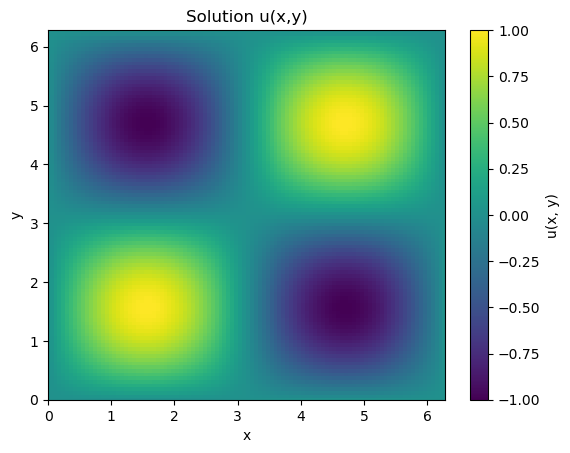

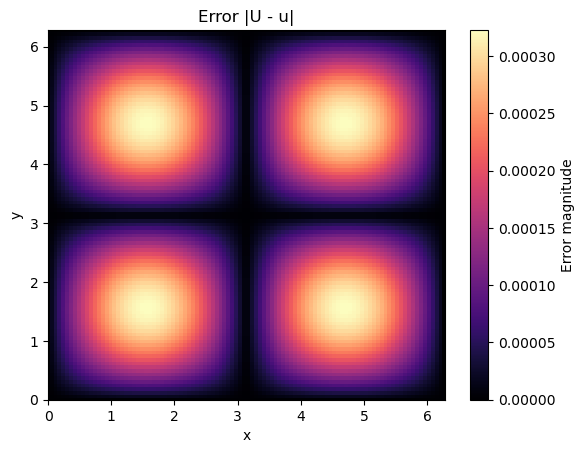

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as linalg

# Problem specification
m = 100
x = np.linspace(0, 2.0 * np.pi, m + 2)
y = np.linspace(0, 2.0 * np.pi, m + 2)
delta_x = 2.0 * np.pi / (m + 1)

# Construct A
e = np.ones(m)
T = sparse.spdiags([e, -4.0 * e, e], [-1, 0, 1], m, m)
S = sparse.spdiags([e, e], [-1, 1], m, m)
I = sparse.eye(m)
A = sparse.kron(I, T) + sparse.kron(S, I)
A /= delta_x**2

# Right-hand-side
X, Y = np.meshgrid(x[1:-1], y[1:-1])
f = -2.0 * np.sin(X) * np.sin(Y)

# Solve
U = np.zeros((m+2, m+2))
U[1:-1, 1:-1] = linalg.spsolve(A, f.reshape(m**2, order='F')).reshape((m, m), order='F')

# Error
X, Y = np.meshgrid(x, y)
print(np.linalg.norm((x[1] - x[0]) * (U - np.sin(X) * np.sin(Y)), ord=1))

# Plot solution with viridis colormap
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
sol_plot = axes.pcolor(X, Y, U, cmap='viridis')
axes.set_title("Solution u(x,y)")
axes.set_xlabel("x")
axes.set_ylabel("y")
axes.set_xlim((0.0, 2.0 * np.pi))
axes.set_ylim((0.0, 2.0 * np.pi))
cbar = fig.colorbar(sol_plot, ax=axes)
cbar.set_label("u(x, y)")

# Plot error with magma colormap
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
sol_plot = axes.pcolor(X, Y, np.abs(U - np.sin(X) * np.sin(Y)), cmap='magma')
axes.set_title("Error |U - u|")
axes.set_xlabel("x")
axes.set_ylabel("y")
axes.set_xlim((0.0, 2.0 * np.pi))
axes.set_ylim((0.0, 2.0 * np.pi))
cbar = fig.colorbar(sol_plot, ax=axes)
cbar.set_label("Error magnitude")
plt.show()